# 실습설명
화장품 이커머스 데이터 분석을 통해, 고객의 이탈율을 낮추고 구매 전환율을 높이는 것이 목표

# 데이터 설명

- event_time : 이벤트가 발생한 시간
- event_type : 이벤트 유형(구매)
- product_id : 제품ID
- category_id : 제품의 카테고리 ID
- category_code : 제품의 카테고리 코드 (의미있는 카테고리의 경우 존재)
- brand : 브랜드 이름 (소문자, 생략될 수 있음)
- price : 제품의 가격
- user_id : 사용자 ID
- user_session : 사용자 세션 ID(임시, 세션마다 변경됨)

In [2]:
import pandas as pd
df  = pd.read_csv("/Users/jangminseul/Desktop/minmmmgz/data/raw/cosmetic.csv")
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00 UTC,remove_from_cart,5712790,1487580005268456287,NaN,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc
1,2019-12-01 00:00:00 UTC,view,5764655,1487580005411062629,NaN,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18
2,2019-12-01 00:00:02 UTC,cart,4958,1487580009471148064,NaN,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554
3,2019-12-01 00:00:05 UTC,view,5848413,1487580007675986893,NaN,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4
4,2019-12-01 00:00:07 UTC,view,5824148,1487580005511725929,NaN,NaN,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5


### 전처리

In [3]:
print(df.shape) # 데이터 개수
print(df.info()) # 컬럼별 타입

(3533286, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3533286 entries, 0 to 3533285
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 242.6+ MB
None


In [4]:
df_raw = df.copy() # 타입변환 데이터
df_raw['event_time'] = pd.to_datetime(df_raw['event_time']) # 데이터 타입 변환
df_raw['event_time'].dtype

df_clean = df_raw.copy() # 전처리용


In [5]:
df_clean.duplicated().sum() # 중복데이터 확인

183860

중복 데이터 원인
- 같은 행동이 동시에 여러번 기록
- 초 단위 timestamp
- 세션 로그 특성

In [6]:
df_clean.duplicated().sum()/len(df_clean) # 중복 데이터 비율 확인

0.052036546149957855

In [7]:
df_clean[df_clean.duplicated()].head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
37,2019-12-01 00:01:52+00:00,cart,5700046,1487580009286598681,NaN,runail,0.40,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc
55,2019-12-01 00:02:49+00:00,cart,5693501,1487580009445982239,NaN,NaN,0.60,579751441,8de492d7-0937-47ae-be2c-a7615aec2b0d
61,2019-12-01 00:03:08+00:00,remove_from_cart,5859482,1487580005671109489,NaN,masura,1.60,561162056,39cf2227-03ed-421e-9615-7814b9b3c5e6
62,2019-12-01 00:03:08+00:00,remove_from_cart,5839671,1487580005671109489,NaN,masura,2.19,561162056,39cf2227-03ed-421e-9615-7814b9b3c5e6
66,2019-12-01 00:03:10+00:00,remove_from_cart,5859482,1487580005671109489,NaN,masura,1.60,561162056,39cf2227-03ed-421e-9615-7814b9b3c5e6


In [8]:
df_clean.duplicated(subset=['user_id','event_time','product_id','event_type']).sum()

185220

In [9]:
df_clean.drop_duplicates(subset=['user_id','event_time','product_id','event_type'])  # 어떤 종류인지 확인
df_clean = df_clean.drop_duplicates(subset=['user_id','event_time','product_id','event_type']) # 같은 사용자가, 같은 시점에, 같은 상품에 대해 같은 행동을 여러번 기록 한 경우로 바라보고 분석하기 위함

In [10]:
print(len(df_clean))
df_clean.duplicated(subset=['user_id','event_time','product_id','event_type']).sum() # 제거확인

3348066


0

In [11]:
print(df_clean.isnull().sum()) # 결측치 확인
(df_clean.isnull().sum()/len(df_clean))*100  # 결측치 비율 확인

event_time             0
event_type             0
product_id             0
category_id            0
category_code    3291359
brand            1427640
price                  0
user_id                0
user_session         714
dtype: int64


event_time        0.000000
event_type        0.000000
product_id        0.000000
category_id       0.000000
category_code    98.306276
brand            42.640736
price             0.000000
user_id           0.000000
user_session      0.021326
dtype: float64

In [12]:
df_clean = df_clean.drop('category_code', axis= 1)

In [13]:
df_clean.isnull().sum()

event_time            0
event_type            0
product_id            0
category_id           0
brand           1427640
price                 0
user_id               0
user_session        714
dtype: int64

In [14]:
df_feat = df_clean.copy() # 브랜드 전처리용
df_feat['brand'] = (df_feat.groupby('product_id')['brand'].transform(lambda x : x.ffill().bfill()))

/var/folders/k6/bbfv75wn1_x_knw1l7grxc7w0000gn/T/ipykernel_4147/1641838922.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_feat['brand'] = (df_feat.groupby('product_id')['brand'].transform(lambda x : x.ffill().bfill()))


In [15]:
(df_feat.isnull().sum()/len(df_feat))*100

event_time       0.000000
event_type       0.000000
product_id       0.000000
category_id      0.000000
brand           42.433841
price            0.000000
user_id          0.000000
user_session     0.021326
dtype: float64

In [16]:
df_feat['brand'] = df_feat['brand'].fillna("Unknown")
df_feat.isna().sum()


event_time        0
event_type        0
product_id        0
category_id       0
brand             0
price             0
user_id           0
user_session    714
dtype: int64

### 데이터 분석

In [44]:
# 이벤트 기준
df_event = df_feat.copy()
df_event['price'].describe() # 수치 분포 확인

print(df_event.head())

df_event[df_event['price'] < 0].shape # (17,9)
(df_event['price'] < 0).mean()
df_event[df_event['price'] < 0].head()
df_event[df_event['price'] < 0]['event_type'].value_counts() # 17

df_event = df_event[df_event['price'] >= 0]

                 event_time        event_type  product_id  \
0 2019-12-01 00:00:00+00:00  remove_from_cart     5712790   
1 2019-12-01 00:00:00+00:00              view     5764655   
2 2019-12-01 00:00:02+00:00              cart        4958   
3 2019-12-01 00:00:05+00:00              view     5848413   
4 2019-12-01 00:00:07+00:00              view     5824148   

           category_id      brand  price    user_id  \
0  1487580005268456287      f.o.x   6.27  576802932   
1  1487580005411062629        cnd  29.05  412120092   
2  1487580009471148064     runail   1.19  494077766   
3  1487580007675986893  freedecor   0.79  348405118   
4  1487580005511725929    Unknown   5.56  576005683   

                           user_session  
0  51d85cb0-897f-48d2-918b-ad63965c12dc  
1  8adff31e-2051-4894-9758-224bfa8aec18  
2  c99a50e8-2fac-4c4d-89ec-41c05f114554  
3  722ffea5-73c0-4924-8e8f-371ff8031af4  
4  28172809-7e4a-45ce-bab0-5efa90117cd5  


In [45]:
df_event['event_type'].value_counts() 
# 퍼널 구조 view -> cart -> purchase
# 중간 이탈 remove_from_cart

event_type
view                1726861
cart                 911641
remove_from_cart     496498
purchase             213049
Name: count, dtype: int64

In [46]:
# 단계별 전환율
view = (df_event['event_type'] == 'view').sum()
cart = (df_event['event_type'] == 'cart').sum()
remove_from_cart = (df_event['event_type'] == 'remove_from_cart').sum()
purchase = (df_event['event_type'] == 'purchase').sum()

view_to_cart = cart / view
cart_to_purchase = purchase / cart
view_to_purchase = purchase / view
remove_rate = remove_from_cart/cart

print(f"view_to_cart : " , view_to_cart)
print(f"cart_to_purchase : " , cart_to_purchase)
print(f"view_to_purchase : " , view_to_purchase)
print(f"remove_rate : " , remove_rate)

view_to_cart :  0.527917996874097
cart_to_purchase :  0.233698352750699
view_to_purchase :  0.12337356625692514
remove_rate :  0.544620086196211


In [48]:
# 가격 구간 생성_이벤트 기준
df_processed_event = df_event.copy()
df_processed_event['price_bin'] = pd.qcut(df_processed_event['price'],q=4, labels= ['Q1','Q2','Q3','Q4'])  # 가격 데이터 4등분
df_processed_event['price_bin'].value_counts()

price_bin
Q2    838318
Q1    837288
Q3    836360
Q4    836083
Name: count, dtype: int64

In [49]:
df_processed_event['price_bin'].isna().sum()

0

In [56]:
# 가격 구간별 전환율 분석_유저 기준
price_funnel = df_processed_event[df_processed_event['event_type'].isin(['view','cart','purchase','remove_from_cart'])]
price_user_funnel = (price_funnel.groupby(['price_bin','user_id','event_type']).size().unstack(fill_value=0).reset_index())

# True/False 변환
for col in ['view','cart','purchase','remove_from_cart'] :
    price_user_funnel[col] = price_user_funnel[col] > 0

price_summary = (price_user_funnel.groupby('price_bin')[['view','cart','purchase','remove_from_cart']].sum())
price_summary['view_to_cart'] = price_summary['cart']/price_summary['view']
price_summary['cart_to_purchase'] = price_summary['purchase']/price_summary['cart']
price_summary['view_to_purchase'] = price_summary['purchase']/price_summary['view']
price_summary['remove_rate'] = price_summary['remove_from_cart']/price_summary['cart']


/var/folders/k6/bbfv75wn1_x_knw1l7grxc7w0000gn/T/ipykernel_4147/731976045.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_user_funnel = (price_funnel.groupby(['price_bin','user_id','event_type']).size().unstack(fill_value=0).reset_index())
/var/folders/k6/bbfv75wn1_x_knw1l7grxc7w0000gn/T/ipykernel_4147/731976045.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_summary = (price_user_funnel.groupby('price_bin')[['view','cart','purchase','remove_from_cart']].sum())


<Axes: xlabel='price_bin'>

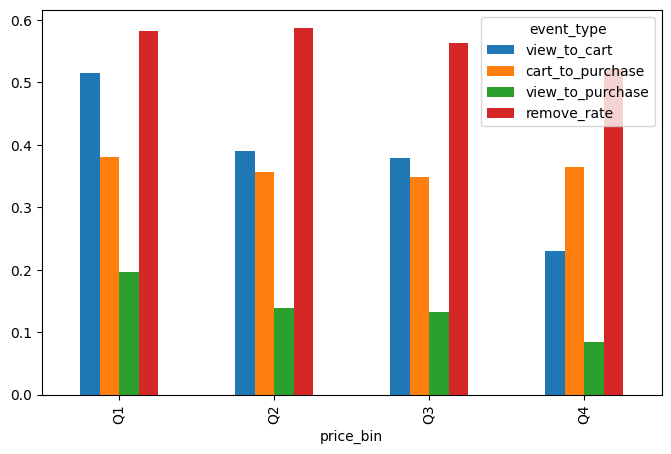

In [57]:
import matplotlib.pyplot as plt
price_summary[['view_to_cart','cart_to_purchase','view_to_purchase','remove_rate']].plot(kind='bar',figsize=(8,5))

In [61]:
# 유저 기준 전환율
summary_c = price_user_funnel.groupby('price_bin')[['view','cart','purchase']].sum()
summary_c['view_to_cart'] = summary_c['cart'] / summary_c['view']
summary_c['cart_to_purchase'] = summary_c['purchase']/summary_c['cart']
summary_c['view_to_purchase'] = summary_c['purchase']/summary_c['view']
summary_c

/var/folders/k6/bbfv75wn1_x_knw1l7grxc7w0000gn/T/ipykernel_4147/1780525132.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_c = price_user_funnel.groupby('price_bin')[['view','cart','purchase']].sum()


event_type,view,cart,purchase,view_to_cart,cart_to_purchase,view_to_purchase
price_bin,,,,,,
Q1,74616,38416,14614,0.514849,0.380414,0.195856
Q2,110003,42980,15323,0.390717,0.356515,0.139296
Q3,120966,45775,15962,0.378412,0.348706,0.131954
Q4,191274,44123,16107,0.230680,0.365048,0.084209


In [59]:
# 유저 기준
summary_u = price_user_funnel.groupby('price_bin')[['cart','remove_from_cart']].sum()
summary_u['remove_rate'] = summary_u['remove_from_cart'] / summary_u['cart']
summary_u



/var/folders/k6/bbfv75wn1_x_knw1l7grxc7w0000gn/T/ipykernel_4147/625281855.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_u = price_user_funnel.groupby('price_bin')[['cart','remove_from_cart']].sum()


event_type,cart,remove_from_cart,remove_rate
price_bin,,,
Q1,38416,22337,0.581450
Q2,42980,25220,0.586785
Q3,45775,25804,0.563714
Q4,44123,22996,0.521179


In [62]:
# 이벤트 기준
remove_df = price_funnel[price_funnel['event_type'].isin(['remove_from_cart','cart'])]
summary_e = (remove_df.groupby(['price_bin','event_type'])).size().unstack(fill_value=0)
summary_e['remove_rate'] = summary_e['remove_from_cart'] / summary_e['cart']
summary_e

/var/folders/k6/bbfv75wn1_x_knw1l7grxc7w0000gn/T/ipykernel_4147/3026365490.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_e = (remove_df.groupby(['price_bin','event_type'])).size().unstack(fill_value=0)


event_type,cart,remove_from_cart,remove_rate
price_bin,,,
Q1,308872,149719,0.484728
Q2,240560,140708,0.584919
Q3,217490,127767,0.587461
Q4,144719,78304,0.541076


In [33]:
## 통계적 유의성 확인
# Q1
view_Q1 = price_summary.loc['Q1', 'view']
cart_Q1 = price_summary.loc['Q1', 'cart']

# Q4
view_Q4 = price_summary.loc['Q4', 'view']
cart_Q4 = price_summary.loc['Q4', 'cart']

from statsmodels.stats.proportion import proportions_ztest

count = [cart_Q1, cart_Q4]   # 성공 (cart)
nobs = [view_Q1, view_Q4]    # 전체 (view)

stat, pval = proportions_ztest(count, nobs)

print("z-stat:", stat)
print("p-value:", pval)

z-stat: 142.29893608973535
p-value: 0.0


## 유저 기준
# 전환율
- view -> cart  (Q1 = 0.51, Q4 = 0.23) => 가격이 오를 수록 장바구니 진입이 감소
- cart -> purchase (Q1 = 0.38, Q4 = 0.36) => 장바구니까지 온 사람은 가격 영향이 크지 않음
- view -> purchase (Q1 = 0.19, Q4 = 0.08) => 감소는 있지만, 급격하진 않음

가격의 영향은 초기 관심형성(view -> cart)에서 크게 작용함
고가 상품은 애초에 장바구니 진입 자체가 어려움

# remove_rate
- Q1과(0.58) Q4(0.52)에서 비슷한 수준의 비율을 보이고 있음 -> 고가일수록 장바구니 제거가 폭증하지는 않음

장바구니에 담긴 후에는 가격의 영향은 크게 받지 않음.

=> 가격은 구매 결정 단계보다는 관심 전환 단계에 더 큰 영향을 준다

## 이벤트 기준(행동강도)
# remove_rate
- Q1(0.48), Q4(0.54) 약 6%정도의 차이를 보임 => 고가일수록 제거 행동(횟수비중)은 증가한다

# 가설 1 
- 고가 제품군일수록 해당 구간 유저 집단에서 1인당 장바구니 제거 행동이 더 자주 발생한다.

In [70]:
# 유저별 remove 횟수
user_repeat = (price_funnel.groupby(['price_bin','user_id','event_type']).size().unstack(fill_value=0).reset_index())

# remove 횟수 생성 (없으면 0)
user_repeat['remove_count'] = user_repeat['remove_from_cart']

user_repeat.groupby('price_bin')['remove_count'].mean()
user_repeat.groupby('price_bin')['remove_count'].describe()

/var/folders/k6/bbfv75wn1_x_knw1l7grxc7w0000gn/T/ipykernel_4147/3710011555.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_repeat = (price_funnel.groupby(['price_bin','user_id','event_type']).size().unstack(fill_value=0).reset_index())
/var/folders/k6/bbfv75wn1_x_knw1l7grxc7w0000gn/T/ipykernel_4147/3710011555.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_repeat.groupby('price_bin')['remove_count'].mean()
/var/folders/k6/bbfv75wn1_x_knw1l7grxc7w0000gn/T/ipykernel_4147/3710011555.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version 

,count,mean,std,min,25%,50%,75%,max
price_bin,,,,,,,,
Q1,370154.0,0.404478,3.960578,0.0,0.0,0.0,0.0,793.0
Q2,370154.0,0.380134,3.307342,0.0,0.0,0.0,0.0,387.0
Q3,370154.0,0.345173,3.660917,0.0,0.0,0.0,0.0,1003.0
Q4,370154.0,0.211544,2.034729,0.0,0.0,0.0,0.0,589.0


Q1(0.4), Q4(0.2) --> 저가일수록 장바구니 제거가 많음.

In [71]:
# cart 한 유저만 필터
user_repeat_c = user_repeat[user_repeat['cart'] > 0]

user_repeat_c['remove_count'] = user_repeat_c['remove_from_cart']
user_repeat_c.groupby('price_bin')['remove_count'].mean()
user_repeat_c.groupby('price_bin')['remove_count'].describe()

/var/folders/k6/bbfv75wn1_x_knw1l7grxc7w0000gn/T/ipykernel_4147/439654629.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_repeat_c['remove_count'] = user_repeat_c['remove_from_cart']
/var/folders/k6/bbfv75wn1_x_knw1l7grxc7w0000gn/T/ipykernel_4147/439654629.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_repeat_c.groupby('price_bin')['remove_count'].mean()
/var/folders/k6/bbfv75wn1_x_knw1l7grxc7w0000gn/T/ipykernel_4147/439654629.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version o

,count,mean,std,min,25%,50%,75%,max
price_bin,,,,,,,,
Q1,38416.0,3.596418,11.614363,0.0,0.0,1.0,3.0,793.0
Q2,42980.0,3.057608,9.020022,0.0,0.0,1.0,3.0,387.0
Q3,45775.0,2.625472,10.015005,0.0,0.0,1.0,2.0,1003.0
Q4,44123.0,1.627632,5.212596,0.0,0.0,0.0,2.0,589.0


# 전체 유저
Q1(0.4), Q4(0.2) --> 저가일수록 장바구니 제거가 많음.
# 카트에 담은 유저만 필터링
Q1(3.6), Q4(1.6) --> 저가일수록 장바구니 제거가 많음